In [13]:
from google.colab import files
import os

# 1. Upload kaggle.json
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Upload your kaggle.json file:")
    files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# 2. Download and Unzip Dataset
if not os.path.exists('dataset'):
    !kaggle datasets download -d bhavikardeshna/visual-question-answering-computer-vision-nlp
    !unzip -q visual-question-answering-computer-vision-nlp.zip -d dataset
    print("✅ Dataset downloaded and unzipped.")

This cell finds CSV and maps answers to numerical labels.

In [14]:
import pandas as pd
import numpy as np

# 1. Find CSV
data_path = 'dataset/data_eval.csv' # Based on your previous output
df = pd.read_csv(data_path)
df.columns = [col.lower() for col in df.columns]

# 2. Map Answers to Labels (Integers)
unique_answers = df['answer'].unique()
ans_to_id = {ans: i for i, ans in enumerate(unique_answers)}
id_to_ans = {i: ans for ans, i in ans_to_id.items()}
df['label'] = df['answer'].map(ans_to_id)

# 3. Find Images Folder
image_dir = 'dataset/images'
sample_img = os.listdir(image_dir)[0]
IMG_EXT = os.path.splitext(sample_img)[1]

print(f"✅ Loaded {len(df)} rows.")
print(f"✅ Number of classes: {len(unique_answers)}")
print(f"✅ Image directory: {image_dir} (Extension: {IMG_EXT})")

✅ Loaded 2494 rows.
✅ Number of classes: 536
✅ Image directory: dataset/images (Extension: .png)


This handles loading the images and tokenizing the text questions.

In [15]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from transformers import AutoTokenizer

class VQADataset(Dataset):
    def __init__(self, dataframe, image_dir, tokenizer, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img_name = str(row['image_id'])
        if not img_name.endswith(IMG_EXT): img_name += IMG_EXT
        image = Image.open(os.path.join(self.image_dir, img_name)).convert('RGB')
        if self.transform: image = self.transform(image)

        # Text
        inputs = self.tokenizer(str(row['question']), padding='max_length',
                                truncation=True, max_length=32, return_tensors="pt")

        return {
            'image': image,
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0),
            'label': torch.tensor(row['label'], dtype=torch.long)
        }

# Initializing Loaders
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

dataset = VQADataset(df, image_dir, tokenizer, transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

This is the "Brain" that combines ResNet (Vision) and DistilBERT (Text).

In [16]:
import torch.nn as nn
from torchvision import models
from transformers import AutoModel

class VQAModel(nn.Module):
    def __init__(self, num_classes):
        super(VQAModel, self).__init__()
        # Vision Branch
        resnet = models.resnet18(weights='DEFAULT')
        self.vision_backbone = nn.Sequential(*list(resnet.children())[:-1])

        # Text Branch
        self.text_backbone = AutoModel.from_pretrained("distilbert-base-uncased")

        # Fusion Classifier
        self.classifier = nn.Sequential(
            nn.Linear(512 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, image, input_ids, attention_mask):
        img_features = self.vision_backbone(image).view(image.size(0), -1)
        text_outputs = self.text_backbone(input_ids=input_ids, attention_mask=attention_mask)
        text_features = text_outputs.last_hidden_state[:, 0, :]

        combined = torch.cat((img_features, text_features), dim=1)
        return self.classifier(combined)

# Initialize Model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VQAModel(num_classes=len(unique_answers)).to(DEVICE)
print(f"🚀 Model initialized on {DEVICE}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


🚀 Model initialized on cuda


start the actual learning process.

In [17]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

epochs = 5
model.train()

for epoch in range(epochs):
    print(f"\n--- Epoch {epoch+1}/{epochs} ---")
    for batch_idx, batch in enumerate(dataloader):
        # Move to GPU
        images = batch['image'].to(DEVICE)
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        # Forward
        outputs = model(images, ids, mask) # Correct 3 arguments + self
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_idx % 20 == 0:
            print(f"Batch {batch_idx}/{len(dataloader)} | Loss: {loss.item():.4f}")

print("\n✅ Training Complete!")


--- Epoch 1/5 ---
Batch 0/78 | Loss: 6.2342
Batch 20/78 | Loss: 5.9324
Batch 40/78 | Loss: 5.6195
Batch 60/78 | Loss: 5.2487

--- Epoch 2/5 ---
Batch 0/78 | Loss: 5.1978
Batch 20/78 | Loss: 4.5840
Batch 40/78 | Loss: 4.7809
Batch 60/78 | Loss: 4.7170

--- Epoch 3/5 ---
Batch 0/78 | Loss: 4.0279
Batch 20/78 | Loss: 4.8723
Batch 40/78 | Loss: 4.5274
Batch 60/78 | Loss: 4.0294

--- Epoch 4/5 ---
Batch 0/78 | Loss: 4.1963
Batch 20/78 | Loss: 3.5315
Batch 40/78 | Loss: 3.4505
Batch 60/78 | Loss: 3.5641

--- Epoch 5/5 ---
Batch 0/78 | Loss: 3.2280
Batch 20/78 | Loss: 3.1410
Batch 40/78 | Loss: 3.7360
Batch 60/78 | Loss: 3.5543

✅ Training Complete!


This cell runs the model on your dataset without training it to see how many questions it gets right.

In [18]:
model.eval()
correct = 0
total = 0

print("Evaluating model...")
with torch.no_grad():
    for batch in dataloader:
        images = batch['image'].to(DEVICE)
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)

        outputs = model(images, ids, mask)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"📊 Final Accuracy: {accuracy:.2f}%")

Evaluating model...
📊 Final Accuracy: 44.31%


This code picks a random question from dataset, shows the image, and tells what the model "thought" the answer was.

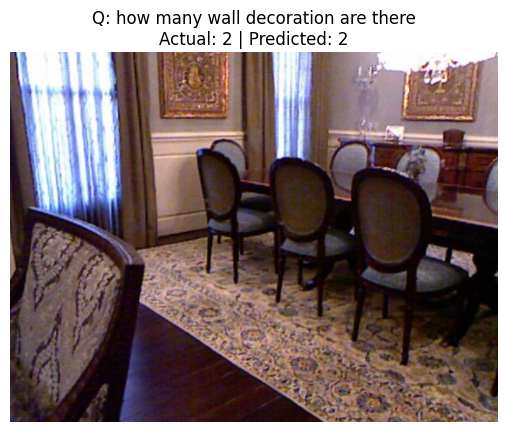

In [19]:
import matplotlib.pyplot as plt

def predict_vqa(index):
    # Get a sample
    row = df.iloc[index]
    image_path = os.path.join(image_dir, str(row['image_id']) + IMG_EXT)
    question = row['question']
    actual_answer = row['answer']

    # Process for model
    image_pil = Image.open(image_path).convert('RGB')
    image_tensor = transform(image_pil).unsqueeze(0).to(DEVICE)

    inputs = tokenizer(question, return_tensors="pt", padding=True, truncation=True).to(DEVICE)

    # Predict
    model.eval()
    with torch.no_grad():
        output = model(image_tensor, inputs['input_ids'], inputs['attention_mask'])
        _, pred_idx = torch.max(output, 1)
        predicted_answer = id_to_ans[pred_idx.item()]

    # Display
    plt.imshow(image_pil)
    plt.title(f"Q: {question}\nActual: {actual_answer} | Predicted: {predicted_answer}")
    plt.axis('off')
    plt.show()

# Test it on a random index
import random
predict_vqa(random.randint(0, len(df)-1))

save model to the Colab local files.

In [20]:
# Save the weights
torch.save(model.state_dict(), 'vqa_model_weights.pth')
print("💾 Model weights saved as 'vqa_model_weights.pth'")

# Optional: Download to your PC
# from google.colab import files
# files.download('vqa_model_weights.pth')

💾 Model weights saved as 'vqa_model_weights.pth'
